# 23장 AI가 문맥을 파악하는 원리

## <목차>

- **23-1. 단어 간 유사성 측정하기**  
- **23-2. 단어들 사이의 관계 파악하기**  
- **23-3. 단어 사이의 관계 수정하기**  
- **23-4. AI가 문맥을 파악하는 법**  
- **23-5. 질문(쿼리), 단서(키), 답변(밸류)**  
- **23-6. 트랜스포머를 위한 어텐션 만들기**  



1.1.) 말을 이해한다 = 단어의 의미를 파악하는 것 (친구에게 사과했다 vs 사과를 먹었다)

1.2.) AI는 이러한 단어 의미 차이를 **단어를 숫자로 바꾸는 임베딩**으로 알아낸다.

다시 말해, 비슷한 뜻을 가진 단어는 비슷한 숫자를 가지기에, **단어 사이의 관계**도 숫자로 나타낼 수 있다.

(AI는 **해당 단어가 들어간 문장의 앞뒤 단어들**을 바탕으로 그 두 단어의 의미 차이를 구별한다.)

1.3.)또한 AI는 문장에서 단어들이 어떻게 연결되어 있는지도 분석할 수 있다.

---

2.1.)이것들을 해내는 모델이 바로 어텐션이다 (**핵심 단어에 더 높은 가중치**를 주는 것)

2.2.)$어텐션의 핵심$ = 단어를 숫자로 바꾼다 (**임베딩**) + 문장 내에서 단어들의 중요도를 파악한다 (**단어 사이의 관계 = 코사인 유사도 기반 내적 값 = 가중치**)

## 23-1 단어 간 유사성 측정하기 = 임베딩과 좌표로 시각화

**컴퓨터가 알아 들을 수 있도록 수치 형태로 변환하기**

1.1.) 단어들을 숫자로 표현하는 임베딩 과정이 필요하다

1.2.)이러한 임베딩이 완료되면, 각 단어들은 **숫자들의 나열 (고차원 공간상의 벡터)**로 표현된다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 단어와 임베딩 벡터 정의
word_embeddings = {
    '귤': np.array([0, 6]),
    '딸기': np.array([0, 5]),
    '수박': np.array([1, 6]),
    '미소짓다': np.array([6, 1]),
    '화내다': np.array([6, 0]),
    '웃다': np.array([5, 0])
}

#출력해 보기
for word, vec in word_embeddings.items():
    print(f"'{word}'의 임베딩 벡터: {vec}")

'귤'의 임베딩 벡터: [0 6]
'딸기'의 임베딩 벡터: [0 5]
'수박'의 임베딩 벡터: [1 6]
'미소짓다'의 임베딩 벡터: [6 1]
'화내다'의 임베딩 벡터: [6 0]
'웃다'의 임베딩 벡터: [5 0]


**단어를 시각화 하기**

1.1.) 벡터 공간 상에 표현된 **단어들 (임베딩된 단어들) 사이의 관계**를 파악하는 방법은. **임베딩 후 각 단어의 위치를 그래프**로 표현하는 것이다

e.g.,행위 그룹에 해당하는 단어들과, 과일 그룹에 해당하는 단어들은 당연히 대략적인 위치가 다를 것이다.

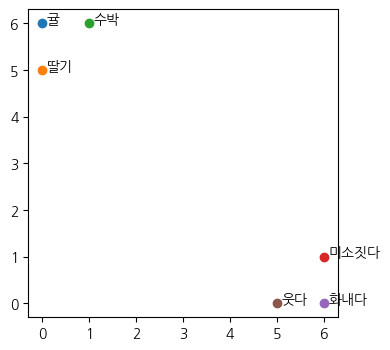

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 단어와 임베딩 벡터 정의
word_embeddings = {
    '귤': np.array([0, 6]),
    '딸기': np.array([0, 5]),
    '수박': np.array([1, 6]),
    '미소짓다': np.array([6, 1]),
    '화내다': np.array([6, 0]),
    '웃다': np.array([5, 0])
}

# 단어 임베딩을 시각화해 봅니다.
plt.figure(figsize=(4, 4))
for word, vec in word_embeddings.items():
    plt.scatter(*vec)
    plt.text(vec[0] + 0.1, vec[1], word)
plt.show()


<주의> 위 그림속 한글이 깨지면, 맨 하단의 [참고] 부분을 참고해 먼저 폰트를 설치하세요.

1.1.) 단어들 사이의 관계를 파악하고 나면, 필요에 따라 **각 단어들을 적절한 위치로 수정해야 한다.**

1.2.) **머신 러닝이란 일단 긋고 수정하여 나가는 학습 과정**이다. 만약 사과를 중간에 위치시킨다면, 문장 앞뒤 단어를 바탕으로, 사과 단어를 이동시킬 수 있다.

1.3.) 먹었다라는 단어가 뒤에 있었다면 과일 그룹으로 이동될 것이며, 어제라는 단어가 있었다면 행위를 나타내는 단어 그룹으로 이동될 것이다.

1.4.)즉 앞뒤 단어라는 **문맥!! 단어가 사용된 환경이 중요한 것이다!! 단어의 의미**를 결정짓는 중요한 요소이다.

## 23-2 단어들 사이의 관계 파악하기 = 코사인 유사도 기반 내적 계산으로 파악.

1.1.) 어텐션이란, 단어 벡터의 위치의 이동을 가능하게 한다.

1.2.) 즉, 단어 벡터들 사이의 내적을 계산하여 **단어 간 거리 (단어간 유사도)**를 파악할 수 있다.

**내적 계산하기**

1.1.) 내적 = **두 벡터 (임베딩된 단어 벡터)의 곱**으로, **두 벡터가 얼마나 유사한 방향**을 가리키는지를 나타내는 척도이다.

1.2.)내적이란 **각 벡터에서, 같은 위치에 있는 값들을 곱한 후, 그 결과를 모두 더하는 식**으로 계산된다.

1.3.)**내적 값이 크다 ? = 두 벡터가 유사하다.** // 내적 값이 0 =두 벡터는 수직을 이루며 전혀 유사하지 않다.

In [ ]:
def dot_product(vec1, vec2):
    return np.dot(vec1, vec2)

# 예제 단어들 사이의 내적 계산
print("귤 • 딸기:", dot_product(word_embeddings['귤'], word_embeddings['딸기']))
print("귤 • 웃다:", dot_product(word_embeddings['귤'], word_embeddings['웃다']))



귤 • 딸기: 30
귤 • 웃다: 0


**코사인 유사도 계산하기**

1.1.) 내적의 값이 너무 클 경우, 직관적인 비교가 어렵다.

1.2.)이를 보정하기 위해, 벡터의 길이로 나누는 **스케일된 내적 (scaled dot product)**방법이나, **각도를 이용하는 코사인 유사도**방법을 사용한다.

1.3.)코사인 유사도는, **두 벡터 간의 각도**를 기반으로 계산된다.

--두 벡터가 같은 방향 = 코사인 유사도는 1

--두 벡터가 직각 방향이면, 코사인 유사도는 0 (서로 무관)

--두 벡터가 다른 방향 = 코사인 유사도 -1

1.4.)코사인 유사도 = **두 벡터 A, B의 내적을 크기의 곱으로 나눈 값**이다. (벡터 절댓값 크기)

In [ ]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
#np.dot은 내적 계산 #np.norm은 벡터 크기 계산

words = list(word_embeddings.keys()) #단어 임베딩 사전의 키(단어) 목록을 리스트로 저장
embedding_vectors = np.array(list(word_embeddings.values())) #단어 임베딩 사전의 값(벡터) 목록을 배열로 저장

# 코사인 유사성 계산
similarities = []
for v1 in embedding_vectors:
    row = []
    for v2 in embedding_vectors:
        row.append(cosine_similarity(v1, v2))
    similarities.append(row)

# 결과 출력
for i in range(len(words)):
    for j in range(len(words)):
        print(f"{words[i]} • {words[j]} 유사성: {similarities[i][j]:.2f}")


귤 • 귤 유사성: 1.00
귤 • 딸기 유사성: 1.00
귤 • 수박 유사성: 0.99
귤 • 미소짓다 유사성: 0.16
귤 • 화내다 유사성: 0.00
귤 • 웃다 유사성: 0.00
딸기 • 귤 유사성: 1.00
딸기 • 딸기 유사성: 1.00
딸기 • 수박 유사성: 0.99
딸기 • 미소짓다 유사성: 0.16
딸기 • 화내다 유사성: 0.00
딸기 • 웃다 유사성: 0.00
수박 • 귤 유사성: 0.99
수박 • 딸기 유사성: 0.99
수박 • 수박 유사성: 1.00
수박 • 미소짓다 유사성: 0.32
수박 • 화내다 유사성: 0.16
수박 • 웃다 유사성: 0.16
미소짓다 • 귤 유사성: 0.16
미소짓다 • 딸기 유사성: 0.16
미소짓다 • 수박 유사성: 0.32
미소짓다 • 미소짓다 유사성: 1.00
미소짓다 • 화내다 유사성: 0.99
미소짓다 • 웃다 유사성: 0.99
화내다 • 귤 유사성: 0.00
화내다 • 딸기 유사성: 0.00
화내다 • 수박 유사성: 0.16
화내다 • 미소짓다 유사성: 0.99
화내다 • 화내다 유사성: 1.00
화내다 • 웃다 유사성: 1.00
웃다 • 귤 유사성: 0.00
웃다 • 딸기 유사성: 0.00
웃다 • 수박 유사성: 0.16
웃다 • 미소짓다 유사성: 0.99
웃다 • 화내다 유사성: 1.00
웃다 • 웃다 유사성: 1.00


[귤과 사과]라는 구문을 이루고 있는 각 단어를 가로/세로 벡터로 놓고, 이들의 내적을 코사인 유사도를 이용해 구해보자.

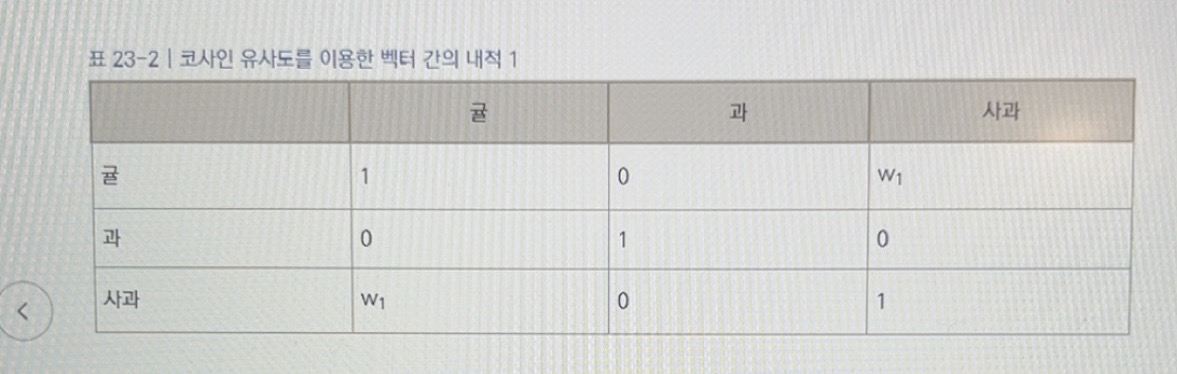

-단어 '귤'과 조사 '과'는 관계가 없으므로 내적 결과는 0 이다.

-귤과 사과의 관계 값은 **w1**으로 표시하였다.

-마찬가지로 [어제일을 사과]라는 구문을 가로/세로벡터로 놓고 이들의 내적을 코사인 유사도로 구한다. 이때 어제일과 사과의 관계 값는 **w2**이다.

-바로 이 $w1, w2$는 각각 귤-사과, 어제일-사과 사이의 **관계가 얼마나 강한지를 반영**한다. 이 값은 **학습 과정을 통해 적절히 조정**되는 것이다.

## 23-3 단어 사이의 관계 수정하기 = 내적을 기반으로 계산한 관계값이 학습을 거치면서 수정 (단어를 알맞은 위치로 이동)

**관계 업데이트**

1.1) 이제 사과의 임베딩을 과일 그룹인가 행위 그룹인가로 이동시킬 차례이다.

1.2.)**어텐션 모델** = 주어진 문장들의 **문맥**을 파악하면서, 그래프 중앙에 위치한 사과라는 단어를, **알맞은 위치로 이동시키는 역할**을 수행한다.

1.3.) 즉, **학습이 진행됨에 따라, 사과의 위치가 문맥에 맞게 조정된다.**

In [ ]:
def update_vector(vector, target_vector, similarity_value, learning_rate):
    new_vector = vector + learning_rate * (target_vector - vector) * similarity_value
    return new_vector

# 기존 딕셔너리에 추가
word_embeddings['사과'] = np.array([3, 3])  # '사과' 초기 값 추가
word_embeddings['과'] = np.array([0, 0])    # '과' 벡터 추가

# 벡터 값 가져오기
귤 = word_embeddings['귤']
사과 = word_embeddings['사과']
과 = word_embeddings['과']

# '귤과 사과' 문장의 각 단어별 코사인 유사도
cosine_귤_사과 = cosine_similarity(귤, 사과)
cosine_과_사과 = cosine_similarity(과, 사과)

# 학습률1의 예 = 벡터가 목표 벡터를 초과하거나 너무 적게 이동하지 않도록 정한 값.
##실제 어텐션 매커니즘에서는 가중치가 자동으로 학습되고, 소프트맥스 함수로 단어 간 중요도가 계산되어 벡터가 적절히 조정되므로, 학습률 조정 필요 x
learning_rate1 = 0.47

# '사과' 벡터를 '귤' 쪽으로 업데이트
print(f"업데이트 이전의 사과 벡터 (사과_?): {사과}")
사과_과일 = update_vector(사과, 귤, cosine_귤_사과, learning_rate1)
print(f"업데이트된 사과 벡터 (사과_과일): {사과_과일}")


업데이트 이전의 사과 벡터 (사과_?): [3 3]
업데이트된 사과 벡터 (사과_과일): [2.003 3.997]


<ipython-input-34-8332a23a41cb>:2: RuntimeWarning: invalid value encountered in scalar divide
  return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


**모두 실행**

업데이트 이전의 사과 벡터 (사과_?): [3 3]
업데이트된 사과 벡터 (사과_과일): [2.003 3.997]
업데이트된 사과 벡터 (사과_행위): [3.9907 2.0093]


<ipython-input-36-265b275e1aec>:15: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product / (norm_v1 * norm_v2)


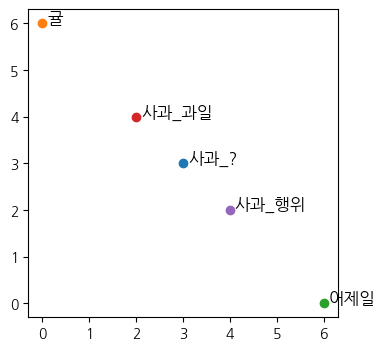

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 초기 벡터값 설정
사과 = np.array([3, 3])
귤 = np.array([0, 6])
과 = np.array([0, 0])
을 = np.array([0, 0])
어제일 = np.array([6, 0])

def cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

def update_vector(vector, target_vector, similarity_value, learning_rate):
    new_vector = vector + learning_rate * (target_vector - vector) * similarity_value
    return new_vector

# '귤과 사과' 문장의 각 단어별 코사인 유사도
cosine_귤_사과 = cosine_similarity(귤, 사과)
cosine_과_사과 = cosine_similarity(과, 사과)

# 학습률1을 설정하겠습니다.
learning_rate1 = 0.47

# '사과' 벡터를 '귤' 쪽으로 업데이트
print(f"업데이트 이전의 사과 벡터 (사과_?): {사과}")
사과_과일 = update_vector(사과, 귤, cosine_귤_사과, learning_rate1)
print(f"업데이트된 사과 벡터 (사과_과일): {사과_과일}")

# '어제일을 사과' 문장의 각 단어별 코사인 유사도
cosine_어제일_사과 = cosine_similarity(어제일, 사과_과일)
cosine_을_사과 = cosine_similarity(을, 사과_과일)

# 학습률2를 설정하겠습니다.
learning_rate2 = 1.11

# '사과' 벡터를 '어제일' 쪽으로 업데이트
사과_행위 = update_vector(사과_과일, 어제일, cosine_어제일_사과, learning_rate2)
print(f"업데이트된 사과 벡터 (사과_행위): {사과_행위}")

# 단어 임베딩 시각화
word_embeddings = {
    "사과_?": 사과,
    "귤": 귤,
    "어제일": 어제일,
    "사과_과일": 사과_과일,
    "사과_행위": 사과_행위
}

plt.figure(figsize=(4, 4))
for word, vec in word_embeddings.items():
    plt.scatter(*vec)
    plt.text(vec[0] + 0.1, vec[1], word, fontsize=12)

plt.show()


## 23-4 AI가 문맥을 파악하는 법 = 실제 임베딩 차원에서 실습해보자

**임베딩 행렬의 형태**

1.1)앞선 예시에서는 두 개의 숫자로만 임베딩했지만, 실제 임베딩은 훨씬 더 많은 숫자를 사용한다. 예를 들어 논문에서는 512개의 임베딩 값을 사용한다.

1.2.) [커피 한잔 어때]라는 입력값이 있을 때, 어텐션 모델은 토큰 (커피, 한잔, 어때)를 512개의 숫자로 임베딩한다! (**각 숫자가 512개의 숫자로 표현되는 것이다**)

1.3.)어텐션에서는 입력 문장의 길이를 미리 지정해두어야 한다. 만약 이 지정된 길이보다 토큰의 수가 적다면, **빈자리 토큰은 패딩으로 채워진다.** (그림 23-6)

In [ ]:
# import numpy as np

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의합니다.
# 실제로는 사전 훈련된 임베딩 벡터를 사용하는 것이 일반적입니다.
embedding_dict = {
    '커피': np.random.rand(512),
    '한잔': np.random.rand(512),
    '어때': np.random.rand(512),
    'PAD': np.zeros(512)  # 패딩 벡터는 0으로 채웁니다.
}

# 입력 문장
sentence = ['커피', '한잔', '어때']
max_len = 4  # 최대 문장 길이
tokens = sentence + ['PAD'] * (max_len - len(sentence))  # 패딩 적용

# 토큰을 임베딩 벡터로 변환
embeddings = np.array([embedding_dict[token] for token in tokens])
print("임베딩 행렬의 형태:", embeddings.shape)  # (4, 512)


임베딩 행렬의 형태: (4, 512)


**각 헤드의 형태**

1.1.) 512개의 숫자로 표현된 토큰들의 내적은 어떻게 효율적으로 구할 수 있는가?

1.2.)**전체 임베딩을 적절한 수로 나누는** 방법이 있다.

1.3.)예를 들어, 512차원 벡터를, 8개의 64차원 벡터로 나누는 것이다.

1.4.)8개의 각 행렬을 어텐션에서는 **헤드**라고 한다.

In [ ]:
num_heads = 8
head_dim = 512 // num_heads  # 각 헤드의 차원

# 임베딩을 8개의 헤드로 분할
heads = np.split(embeddings, num_heads, axis=1)
print("각 헤드의 형태:", heads[0].shape)  # (4, 64)


각 헤드의 형태: (4, 64)


**내적 결과 행렬의 형태**

In [ ]:
# 첫 번째 헤드 선택
head_1 = heads[0]

# 복사1과 복사2 생성
copy1 = head_1 #복사1 행렬 = 해당 헤드를 그대로 복사한 것이다. (4*64)
copy2 = head_1.T #복사2 행렬은 = 해당 헤드 행렬을 전치시킨 것이다 (행과 열을 바꾼 것) (64*4)

# 내적 계산
attention_scores = np.dot(copy1, copy2)
print("내적 결과 행렬의 형태:", attention_scores.shape)  # (4, 4)


내적 결과 행렬의 형태: (4, 4)


**복원된 헤드의 형태**

1.1) 내적 결과 행렬 (4,4)를 4,64 행렬로 복원하는 과정

In [ ]:
# 복사3 생성
copy3 = embeddings[:, :head_dim] #4*64 행렬로 생성

# 다시 4x64 형태로 변환
restored_head = np.dot(attention_scores, copy3)
print("복원된 헤드의 형태:", restored_head.shape)  # (4, 64)


복원된 헤드의 형태: (4, 64)


**최종 출력 행렬의 형태**

1.1.)모든 헤드의 결과를 하나로 통합하여 구현

In [ ]:
restored_heads = []

for i in range(num_heads):
    head = heads[i]
    copy1 = head
    copy2 = head.T
    attention_scores = np.dot(copy1, copy2)
    copy3 = embeddings[:, i*head_dim:(i+1)*head_dim]
    restored_head = np.dot(attention_scores, copy3)
    restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output = np.concatenate(restored_heads, axis=1)
print("최종 출력 행렬의 형태:", final_output.shape)  # (4, 512)


최종 출력 행렬의 형태: (4, 512)


**전체 실행**

In [ ]:
import numpy as np

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의합니다.
embedding_dict = {
    '커피': np.random.rand(512),
    '한잔': np.random.rand(512),
    '어때': np.random.rand(512),
    'PAD': np.zeros(512)  # 패딩 벡터는 0으로 채웁니다.
}

# 입력 문장
sentence = ['커피', '한잔', '어때']
max_len = 4  # 최대 문장 길이
tokens = sentence + ['PAD'] * (max_len - len(sentence))  # 패딩 적용

# 토큰을 임베딩 벡터로 변환
embeddings = np.array([embedding_dict[token] for token in tokens])
print("임베딩 행렬의 형태:", embeddings.shape)  # (4, 512)

# 임베딩을 8개의 헤드로 분할
num_heads = 8
head_dim = 512 // num_heads  # 각 헤드의 차원

# 임베딩을 8개의 헤드로 분할
heads = np.split(embeddings, num_heads, axis=1)
print("각 헤드의 형태:", heads[0].shape)  # (4, 64)

# 각 헤드간의 내적 계산 및 복원
restored_heads = []

for i in range(num_heads):
    head = heads[i] # i번째 헤드 선택
    copy1 = head # 첫 번째 복사본
    copy2 = head.T # 두 번째 복사본 (전치)
    attention_scores = np.dot(copy1, copy2) # 내적 계산 (4x4 행렬)
    copy3 = embeddings[:, i*head_dim:(i+1)*head_dim] # 복사3 생성 (4x64)
    restored_head = np.dot(attention_scores, copy3) #내적 결과와 복사3을 곱하여 복원 (4x64)
    restored_heads.append(restored_head) # 복원된 헤드를 리스트에 추가

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output = np.concatenate(restored_heads, axis=1)
print("최종 출력 행렬의 형태:", final_output.shape)  # (4, 512)


임베딩 행렬의 형태: (4, 512)
각 헤드의 형태: (4, 64)
최종 출력 행렬의 형태: (4, 512)


## 23-5 질문(쿼리), 단서(키), 답변(밸류)의 의미와 스케일링 (어텐션 스코어 및 패딩 처리)

**쿼리, 키, 밸류**

In [ ]:
# 쿼리, 키, 밸류 행렬 초기화
num_heads = 8
head_dim = 512 // num_heads  # 각 헤드의 차원
heads = np.split(embeddings, num_heads, axis=1)
queries = heads.copy()
keys = [head.T for head in heads]
values = heads.copy()

print("쿼리 행렬의 형태:", queries[0].shape)  # (4, 64) = 복사 1 = 쿼리, 질문을 던진다. (이 부분의 문맥을 파악하라!!)
print("키 행렬의 형태:", keys[0].shape)  # (64, 4) = 전치한 복사 2 = 키 = 질문에 답하기 위한 단서를 준다.
print("밸류 행렬의 형태:", values[0].shape)  # (4, 64) = 복사 3 = 최종 답을 구하기 위해 복사 3 행렬을 쓴다.


쿼리 행렬의 형태: (4, 64)
키 행렬의 형태: (64, 4)
밸류 행렬의 형태: (4, 64)


**스케일링 전 어텐션 스코어**

1.1.) 쿼리, 키의 내적 값이 너무 크다면, 계산이 복잡해지고 효율이 떨어지기에, 적절한 크기로 조정하는 **스케일링**이 필요하다.

1.2.)해당 헤드의 길이의 제곱근으로 내적 값을 나눠 준다 (루트 64) = **스케일된 내적**이라고 부른다.

In [ ]:
# 스케일링 전
attention_scores = np.dot(queries[0], keys[0])
print("스케일링 전 어텐션 스코어:")
print(attention_scores)

# 스케일링을 위한 헤드 차원의 제곱근 계산
scaling_factor = np.sqrt(head_dim)

# 스케일링 후
scaled_attention_scores = attention_scores / scaling_factor
print("스케일링 후 어텐션 스코어:")
print(scaled_attention_scores)


스케일링 전 어텐션 스코어:
[[24.0274 19.2221 17.2669  0.    ]
 [19.2221 25.4512 15.7371  0.    ]
 [17.2669 15.7371 19.3056  0.    ]
 [ 0.      0.      0.      0.    ]]
스케일링 후 어텐션 스코어:
[[3.0034 2.4028 2.1584 0.    ]
 [2.4028 3.1814 1.9671 0.    ]
 [2.1584 1.9671 2.4132 0.    ]
 [0.     0.     0.     0.    ]]


**소프트맥스 적용 후 어텐션 스코어**

1.1.) 또한 추가적인 계산 효율을 위해 소프트맥스가 활용된다.

1.2.)이는 각 원소의 값이 0~1이며, 모든 원소의 합이 1이 되도록 만든다는 뜻이다.

1.3.)**패딩으로 채운 부분의 소프트맥스 결과는 0**이여야 한다. 그렇게 만들기 위해서 패딩으로 채운 부분은 -infinite로 정하여, 소프트맥스 진행 시 0이 되도록 한다.

In [ ]:
# 패딩 부분을 -∞로 채운 마스크 행렬 준비
mask = np.zeros_like(scaled_attention_scores)
mask[:, -1] = -np.inf  # 마지막 열을 패딩 처리
mask[-1, :] = -np.inf  # 마지막 행을 패딩 처리

# 소프트맥스 적용 함수
def masked_softmax(x, mask):
    x_exp = np.exp(x - np.max(x, axis=-1, keepdims=True))  # 오버플로 방지
    x_exp = x_exp * (mask != -np.inf)  # 마스크된 부분은 0으로 처리
    x_sum = np.sum(x_exp, axis=-1, keepdims=True) # 지수 값의 합 계산
    x_sum = np.where(x_sum == 0, 1, x_sum)  # 0으로 나누는 것을 방지하기 위해 합이 0인 경우 1로 설정
    return x_exp / x_sum # 소프트맥스 계산

# 소프트맥스 적용
attention_probs = masked_softmax(scaled_attention_scores, mask)
print("소프트맥스 적용 후 어텐션 스코어:")
print(attention_probs)


소프트맥스 적용 후 어텐션 스코어:
[[0.5056 0.2773 0.2172 0.    ]
 [0.2614 0.5695 0.1691 0.    ]
 [0.3209 0.265  0.414  0.    ]
 [0.     0.     0.     0.    ]]


**전체 실행**

In [ ]:
import numpy as np

# 전체 출력 형식을 소수점 이하 네 자리로 설정
np.set_printoptions(precision=4, suppress=True)

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의합니다.
embedding_dict = {
    '커피': np.random.rand(512),
    '한잔': np.random.rand(512),
    '어때': np.random.rand(512),
    'PAD': np.zeros(512)  # 패딩 벡터는 0으로 채웁니다.
}

# 입력 문장
sentence = ['커피', '한잔', '어때']
max_len = 4  # 최대 문장 길이
tokens = sentence + ['PAD'] * (max_len - len(sentence))  # 패딩 적용

# 토큰을 임베딩 벡터로 변환
embeddings = np.array([embedding_dict[token] for token in tokens])
print("임베딩 행렬의 형태:", embeddings.shape)  # (4, 512)

# 쿼리, 키, 밸류 행렬 초기화
num_heads = 8
head_dim = 512 // num_heads  # 각 헤드의 차원
heads = np.split(embeddings, num_heads, axis=1)
queries = heads.copy()
keys = [head.T for head in heads]
values = heads.copy()

print("쿼리 행렬의 형태:", queries[0].shape)  # (4, 64)
print("키 행렬의 형태:", keys[0].shape)  # (64, 4)
print("밸류 행렬의 형태:", values[0].shape)  # (4, 64)

# 2. 스케일링 전후의 결과
# 스케일링 전
attention_scores = np.dot(queries[0], keys[0])
print("스케일링 전 어텐션 스코어:")
print(attention_scores)

# 스케일링을 위한 헤드 차원의 제곱근 계산
scaling_factor = np.sqrt(head_dim)

# 스케일링 후
scaled_attention_scores = attention_scores / scaling_factor
print("스케일링 후 어텐션 스코어:")
print(scaled_attention_scores)

# 3. 어텐션 스코어 계산 및 소프트맥스 적용 전후의 결과

# 패딩 부분을 -∞로 채운 마스크 행렬 준비
mask = np.zeros_like(scaled_attention_scores)
mask[:, -1] = -np.inf  # 예시로 마지막 열을 패딩 처리
mask[-1, :] = -np.inf  # 예시로 마지막 행을 패딩 처리

# 소프트맥스 적용 함수
def masked_softmax(x, mask):
    x_exp = np.exp(x - np.max(x, axis=-1, keepdims=True))  # 오버플로 방지
    x_exp = x_exp * (mask != -np.inf)  # 마스크된 부분은 0으로 처리
    x_sum = np.sum(x_exp, axis=-1, keepdims=True)
    x_sum = np.where(x_sum == 0, 1, x_sum)  # 0으로 나누는 것을 방지
    return x_exp / x_sum

# 소프트맥스 적용
attention_probs = masked_softmax(scaled_attention_scores, mask)
print("소프트맥스 적용 후 어텐션 스코어:")
print(attention_probs)

# 복원된 헤드를 저장할 리스트
restored_heads = []

for i in range(num_heads):
    query = queries[i]
    key = keys[i]
    value = values[i]

    # 내적 계산 후 스케일링
    attention_scores = np.dot(query, key) / scaling_factor

    # 패딩 처리
    padding_mask = (np.array(tokens) == 'PAD').astype(float)
    padding_mask = np.tile(padding_mask, (attention_scores.shape[0], 1))
    attention_scores = np.where(padding_mask, -np.inf, attention_scores)

    # 소프트맥스 적용
    attention_weights = masked_softmax(attention_scores, padding_mask)

    # 밸류와의 곱셈
    restored_head = np.dot(attention_weights, value)
    restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output = np.concatenate(restored_heads, axis=1)
print("최종 출력 행렬의 형태:", final_output.shape)  # (4, 512)


임베딩 행렬의 형태: (4, 512)
쿼리 행렬의 형태: (4, 64)
키 행렬의 형태: (64, 4)
밸류 행렬의 형태: (4, 64)
스케일링 전 어텐션 스코어:
[[27.8396 18.1708 17.4734  0.    ]
 [18.1708 21.1972 15.8224  0.    ]
 [17.4734 15.8224 19.0299  0.    ]
 [ 0.      0.      0.      0.    ]]
스케일링 후 어텐션 스코어:
[[3.48   2.2713 2.1842 0.    ]
 [2.2713 2.6497 1.9778 0.    ]
 [2.1842 1.9778 2.3787 0.    ]
 [0.     0.     0.     0.    ]]
소프트맥스 적용 후 어텐션 스코어:
[[0.636  0.1899 0.1741 0.    ]
 [0.312  0.4554 0.2326 0.    ]
 [0.3302 0.2686 0.4011 0.    ]
 [0.     0.     0.     0.    ]]
최종 출력 행렬의 형태: (4, 512)


## 23-6 트랜스포머를 위한 어텐션 만들기 = 멀티헤드 어텐션의 원리 및 패딩 마스킹

**여러 문장의 임베딩**

1.1.) 여러 문장이 학습을 위해 입력된다면, 모델이 **각 문장의 시작과 끝을 인식할 수 있도록 sos, eos를 붙여주어야 한다.** (start/end of sentence)

In [ ]:
# 입력 문장
sentences = [
    ['<sos>', '커피', '한잔', '어때', '<eos>'],
    ['<sos>', '오늘', '날씨', '좋네', '<eos>'],
    ['<sos>', '옷이', '어울려요', '<eos>', 'PAD']
]

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의합니다.
embedding_dict = {
    '<sos>': np.random.rand(512),
    '<eos>': np.random.rand(512),
    '커피': np.random.rand(512),
    '한잔': np.random.rand(512),
    '어때': np.random.rand(512),
    '오늘': np.random.rand(512),
    '날씨': np.random.rand(512),
    '좋네': np.random.rand(512),
    '옷이': np.random.rand(512),
    '어울려요': np.random.rand(512),
    'PAD': np.zeros(512)  # 패딩 벡터는 0으로 채웁니다.
}

max_len = 5  # 최대 문장 길이

# 토큰을 임베딩 벡터로 변환
embeddings = np.array([[embedding_dict[token] for token in sentence] for sentence in sentences])
print("임베딩 행렬의 형태:", embeddings.shape)  # (3, 5, 512) 그림 23-14 참고


임베딩 행렬의 형태: (3, 5, 512)


**여러 문장에서의 키, 쿼리, 밸류**

1.1.) 여러 문장에서는 각 문장이 **배치**로 묶여 있다.  (3, 5, 512) = 3개의 문장이 배치로 묶여 있으며, 5개의 토큰으로 구성되며, 각 토큰은 512차원 벡터로 표현된다.

1.2.) 배치 = 몇 개의 문장을 입력 값으로 쓸 것인가

e.g., 이 경우 문장이 많지 않으므로, 3개를 모두 입력값으로 둔 것

1.3.)주목할 점 = 여러 개의 문장이 입력되어도 **각 독립적으로 어텐션 스코어가 계산**된다는 것!

1.4.)왜냐하면, **각 문장이 서로 다른 문맥을 가지고 있기 때문에, 하나의 문장이 다른 문장의 정보에 영향을 받지 않도록 독립적으로 처리**해야 한다.

1.5.)이를 위해, **각 문장은 자신만의 고유한 쿼리, 키, 밸류 행렬을 생성하고, 어텐션 스코어를 계산하게 된다.**


---

2.1.)이전에는 하나의 문장 입력에 대하여, 패딩 토큰 처리를 하였다

=**패딩 토큰의 위치**를 찾아서, 해당 위치의 어텐션 스코어를 무한대로 설정하여, 소프트맥스 값이 0이 되도록 설정하였다.

2.2.)그러나, 여러 문장을 한 번에 배치로 처리할 때는 위의 방식은 적용하기 어렵다.

2.3.)따라서, 여러 문장을 동시에 처리할 수 있도록 개선하기 위해, **마스크 배열**을 만든다.

2.4.)다시 말해, **패딩 토큰이 있는 자리는 True, 없는 자리는 False**로 표시하는 것이다.

2.5.)3개의 문장에 대한 마스크 배열의 형태 = (배치크기, 문장길이) = (3, 5)

2.6.)어텐션스코어 = (배치크기, 문장 길이, 문장길이) 형태임

2.7.)이에 따라, 마스크 배열의 차원을 (배치크기, 1, 문장길이)로 확장하여 (3, 1, 5)가 되도록 함. #여기서 1 = 새로운 차원의 크기가 1이다.

2.8.)이러한 식으로 **어텐션 스코어와 마스크 배열의 차원을 같게 맞춰줌.**


In [ ]:
# 쿼리, 키, 밸류 행렬 초기화
##3개의 문장이 동시에 입력되면, 쿼리, 키, 밸류 행렬은 (배치 크기, 문장 길이, 헤드 차원)형태로 초기화된다.
num_heads = 8
head_dim = 512 // num_heads  # 각 헤드의 차원
heads = np.split(embeddings, num_heads, axis=2) # 512차원 임베딩 벡터를 8개의 헤드로 분할하여 heads에 저장 #axis=3, 3번째 축 (512차원 임베딩벡터가 있는)을 기준으로 헤드를 분할하겠다.
queries = heads.copy()
keys = [head.transpose(0, 2, 1) for head in heads] # 키 행렬을 각 헤드의 전치를 통해 초기화 (첫 번째 축: 배치 크기, 두 번째 축: 문장 길이, 세 번째 축: 헤드 차원)
values = heads.copy()

print("쿼리 행렬의 형태:", queries[0].shape)  # (3, 5, 64)
print("키 행렬의 형태:", keys[0].shape)  # (3, 64, 5)
print("밸류 행렬의 형태:", values[0].shape)  # (3, 5, 64)


쿼리 행렬의 형태: (3, 5, 64)
키 행렬의 형태: (3, 64, 5)
밸류 행렬의 형태: (3, 5, 64)


**전체 코드**

In [ ]:
import numpy as np

# 전체 출력 형식을 소수점 이하 네 자리로 설정
np.set_printoptions(precision=4, suppress=True)

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의합니다.
embedding_dict = {
    '<sos>': np.random.rand(512),
    '<eos>': np.random.rand(512),
    '커피': np.random.rand(512),
    '한잔': np.random.rand(512),
    '어때': np.random.rand(512),
    '오늘': np.random.rand(512),
    '날씨': np.random.rand(512),
    '좋네': np.random.rand(512),
    '옷이': np.random.rand(512),
    '어울려요': np.random.rand(512),
    'PAD': np.zeros(512)  # 패딩 벡터는 0으로 채웁니다.
}

# 입력 문장
sentences = [
    ['<sos>', '커피', '한잔', '어때', '<eos>'],
    ['<sos>', '오늘', '날씨', '좋네', '<eos>'],
    ['<sos>', '옷이', '어울려요', '<eos>', 'PAD']
]
max_len = 5  # 최대 문장 길이

# 토큰을 임베딩 벡터로 변환
embeddings = np.array([[embedding_dict[token] for token in sentence] for sentence in sentences])
print("임베딩 행렬의 형태:", embeddings.shape)  # (3, 5, 512)

# 쿼리, 키, 밸류 행렬 초기화
num_heads = 8
head_dim = 512 // num_heads  # 각 헤드의 차원
heads = np.split(embeddings, num_heads, axis=2)  # 512차원 임베딩 벡터를 8개의 헤드로 분할하여 heads에 저장
queries = heads.copy()
keys = [head.transpose(0, 2, 1) for head in heads]  # 키 행렬을 각 헤드의 전치를 통해 초기화 (첫 번째 축: 배치 크기, 두 번째 축: 문장 길이, 세 번째 축: 헤드 차원)
values = heads.copy()

print("쿼리 행렬의 형태:", queries[0].shape)  # (3, 5, 64)
print("키 행렬의 형태:", keys[0].shape)  # (3, 64, 5)
print("밸류 행렬의 형태:", values[0].shape)  # (3, 5, 64)

# 특정 토큰 (커피, 한잔, 어때)의 인덱스
tokens_of_interest = ['커피', '한잔', '어때']
indices_of_interest = [sentences[0].index(token) for token in tokens_of_interest]

# 어텐션 이전의 임베딩 테이블 중 특정 토큰들의 평균 값 계산
print("어텐션 이전의 임베딩 테이블 중 '커피', '한잔', '어때' 토큰의 평균 값:")
initial_avg = np.mean(embeddings[0, indices_of_interest, :], axis=1)
print(initial_avg)

# 스케일링 및 어텐션 스코어 계산
attention_scores = np.matmul(queries[0], keys[0])
scaling_factor = np.sqrt(head_dim)
scaled_attention_scores = attention_scores / scaling_factor

# 패딩 처리 (마스크 배열)
mask = np.array([[token == 'PAD' for token in sentence] for sentence in sentences])
mask = mask[:, np.newaxis, :]  # 차원을 맞추기 위해 확장 (3,5)를 (3,1,5)로
scaled_attention_scores = np.where(mask, -np.inf, scaled_attention_scores)

# 소프트맥스 적용 함수
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# 복원된 헤드를 저장할 리스트
restored_heads = []

for i in range(num_heads):
    query = queries[i]
    key = keys[i]
    value = values[i]

    # 내적 계산 후 스케일링
    attention_scores = np.matmul(query, key) / scaling_factor

    # 패딩 처리
    mask = np.array([[token == 'PAD' for token in sentence] for sentence in sentences])
    mask = mask[:, np.newaxis, :]  # 차원을 맞추기 위해 확장
    attention_scores = np.where(mask, -np.inf, attention_scores)

    # 소프트맥스 적용
    attention_weights = softmax(attention_scores)

    # 밸류와의 곱셈
    restored_head = np.matmul(attention_weights, value)
    restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output = np.concatenate(restored_heads, axis=2)

# 어텐션 이후의 결과 중 특정 토큰들의 평균 값 계산
print("어텐션 이후의 결과 중 '커피', '한잔', '어때' 토큰의 평균 값:")
final_avg = np.mean(final_output[0, indices_of_interest, :], axis=1)
print(final_avg)


임베딩 행렬의 형태: (3, 5, 512)
쿼리 행렬의 형태: (3, 5, 64)
키 행렬의 형태: (3, 64, 5)
밸류 행렬의 형태: (3, 5, 64)
어텐션 이전의 임베딩 테이블 중 '커피', '한잔', '어때' 토큰의 평균 값:
[0.4827 0.4775 0.4829]
어텐션 이후의 결과 중 '커피', '한잔', '어때' 토큰의 평균 값:
[0.4935 0.4926 0.4939]


## [참고] 그림 속 폰트가 깨지면 실행하세요.

<1> 아래 코드를 실행해 필요한 폰트를 설치합니다.

In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

<2> 위 메뉴에서 "런타임 > 세션 다시 시작"을 클릭해서 런타임을 재시작합니다.

<3> 아래 코드를 실행해 설치된 폰트를 확인합니다.

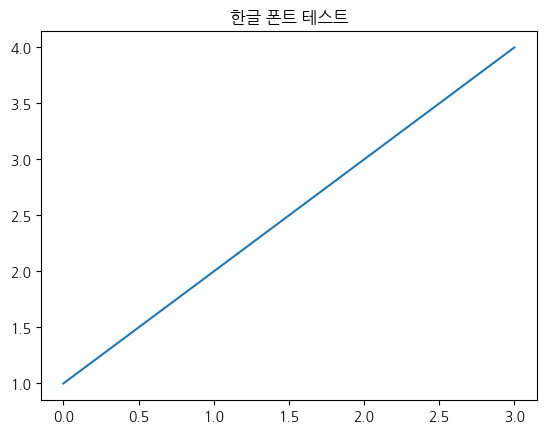

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.plot([1, 2, 3, 4])
plt.title('한글 폰트 테스트')
plt.show()